In [17]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df=pd.read_csv('C:\\Users\\salma\\Downloads\\data_analysis_NTI\\python\\task3\\AmesHousing.csv')

In [3]:
df.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500
9,10,527162130,60,RL,60.0,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,189000


In [11]:
# show all columns in the dataframe 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [6]:
df.shape

(2930, 82)

In [21]:
# check for duplicates in the dataframe
df.duplicated().sum()

0

In [30]:
df.isna().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [35]:
# check for correlation between the columns in the dataframe numeric columns
df.select_dtypes(include=['number']).corr()

,Order,PID,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
Order,1.000000,0.173593,-0.001174,0.031354,-0.048500,-0.011054,-0.052319,-0.075566,-0.030907,-0.032321,-0.002773,0.005780,-0.028719,-0.013201,-0.000417,0.013589,-0.009342,-0.042539,0.024978,-0.044985,-0.039749,0.015424,-0.017685,0.002612,-0.019156,-0.051160,-0.036185,-0.035435,-0.011292,0.016355,0.027908,-0.024975,0.004307,0.052518,-0.006083,0.133365,-0.975993,-0.031408
PID,0.173593,1.000000,-0.092361,0.034868,-0.263147,0.104451,-0.343388,-0.157111,-0.229283,-0.098375,-0.001145,-0.087707,-0.189642,-0.141902,-0.003289,0.056940,-0.107579,-0.037759,0.004328,-0.171431,-0.166636,0.006345,0.076470,-0.068981,-0.108056,-0.256829,-0.237484,-0.210606,-0.051135,-0.071311,0.162519,-0.024894,-0.025735,-0.002845,-0.008260,-0.050455,0.009579,-0.246521
Lot Frontage,-0.001174,-0.092361,1.000000,0.345659,0.189162,-0.062477,0.107537,0.079392,0.196527,0.190882,0.030723,0.106613,0.315507,0.405369,0.037593,0.005331,0.346605,0.095847,-0.025172,0.162316,0.044987,0.219503,0.005744,0.323530,0.222547,0.068471,0.277078,0.325940,0.099137,0.150883,0.009886,0.015593,0.071181,0.148622,0.025309,0.011407,-0.013156,0.328533
Lot Area,0.031354,0.034868,0.345659,1.000000,0.097188,-0.034759,0.023258,0.021682,0.126830,0.191555,0.083150,0.023658,0.253589,0.332235,0.032996,0.000812,0.285599,0.125877,0.026903,0.127433,0.035497,0.136569,-0.020301,0.216597,0.256989,-0.008952,0.179512,0.212822,0.157212,0.103760,0.021868,0.016243,0.055044,0.093775,0.069188,0.003859,-0.023085,0.266549
Overall Qual,-0.048500,-0.263147,0.189162,0.097188,1.000000,-0.094812,0.597027,0.569609,0.429418,0.284118,-0.041287,0.270058,0.547294,0.477837,0.241402,-0.048680,0.570556,0.167858,-0.041647,0.522263,0.268853,0.063291,-0.159744,0.380693,0.393007,0.570569,0.599545,0.563503,0.255663,0.298412,-0.140332,0.018240,0.041615,0.030399,0.005179,0.031103,-0.020719,0.799262
Overall Cond,-0.011054,0.104451,-0.062477,-0.034759,-0.094812,1.000000,-0.368773,0.047680,-0.135340,-0.050935,0.041134,-0.136819,-0.173344,-0.157052,0.006218,0.009175,-0.115643,-0.042766,0.084455,-0.214316,-0.088127,-0.006137,-0.086386,-0.089816,-0.031702,-0.326017,-0.181557,-0.153754,0.020344,-0.068934,0.071459,0.043852,0.044055,-0.016787,0.034056,-0.007295,0.031207,-0.101697
Year Built,-0.052319,-0.343388,0.107537,0.023258,0.597027,-0.368773,1.000000,0.612095,0.313292,0.279870,-0.027415,0.128998,0.407526,0.310463,0.016828,-0.144282,0.241726,0.211849,-0.030626,0.469406,0.269268,-0.055093,-0.137852,0.111919,0.170672,0.834849,0.537443,0.480131,0.228964,0.198365,-0.374364,0.015803,-0.041436,0.002213,-0.011011,0.014577,-0.013197,0.558426
Year Remod/Add,-0.075566,-0.157111,0.079392,0.021682,0.569609,0.047680,0.612095,1.000000,0.196928,0.151790,-0.062129,0.164805,0.297481,0.242108,0.158939,-0.060365,0.316855,0.134387,-0.046292,0.457266,0.211771,-0.021536,-0.142404,0.197528,0.133322,0.652310,0.425403,0.376438,0.217857,0.241748,-0.220383,0.037412,-0.046888,-0.011410,-0.003132,0.018048,0.032652,0.532974
Mas Vnr Area,-0.030907,-0.229283,0.196527,0.126830,0.429418,-0.135340,0.313292,0.196928,1.000000,0.301872,-0.016019,0.091668,0.397040,0.395736,0.121805,-0.057701,0.403611,0.140113,0.015421,0.260153,0.192965,0.080546,-0.050998,0.279563,0.272068,0.254784,0.360159,0.373458,0.165467,0.143748,-0.110787,0.013778,0.065643,0.004617,0.044934,-0.000276,-0.017715,0.508285
BsmtFin SF 1,-0.032321,-0.098375,0.190882,0.191555,0.284118,-0.050935,0.279870,0.151790,0.301872,1.000000,-0.054129,-0.477875,0.536547,0.457472,-0.164014,-0.066173,0.209633,0.640020,0.077548,0.077772,-0.008457,-0.118959,-0.086738,0.047631,0.2958

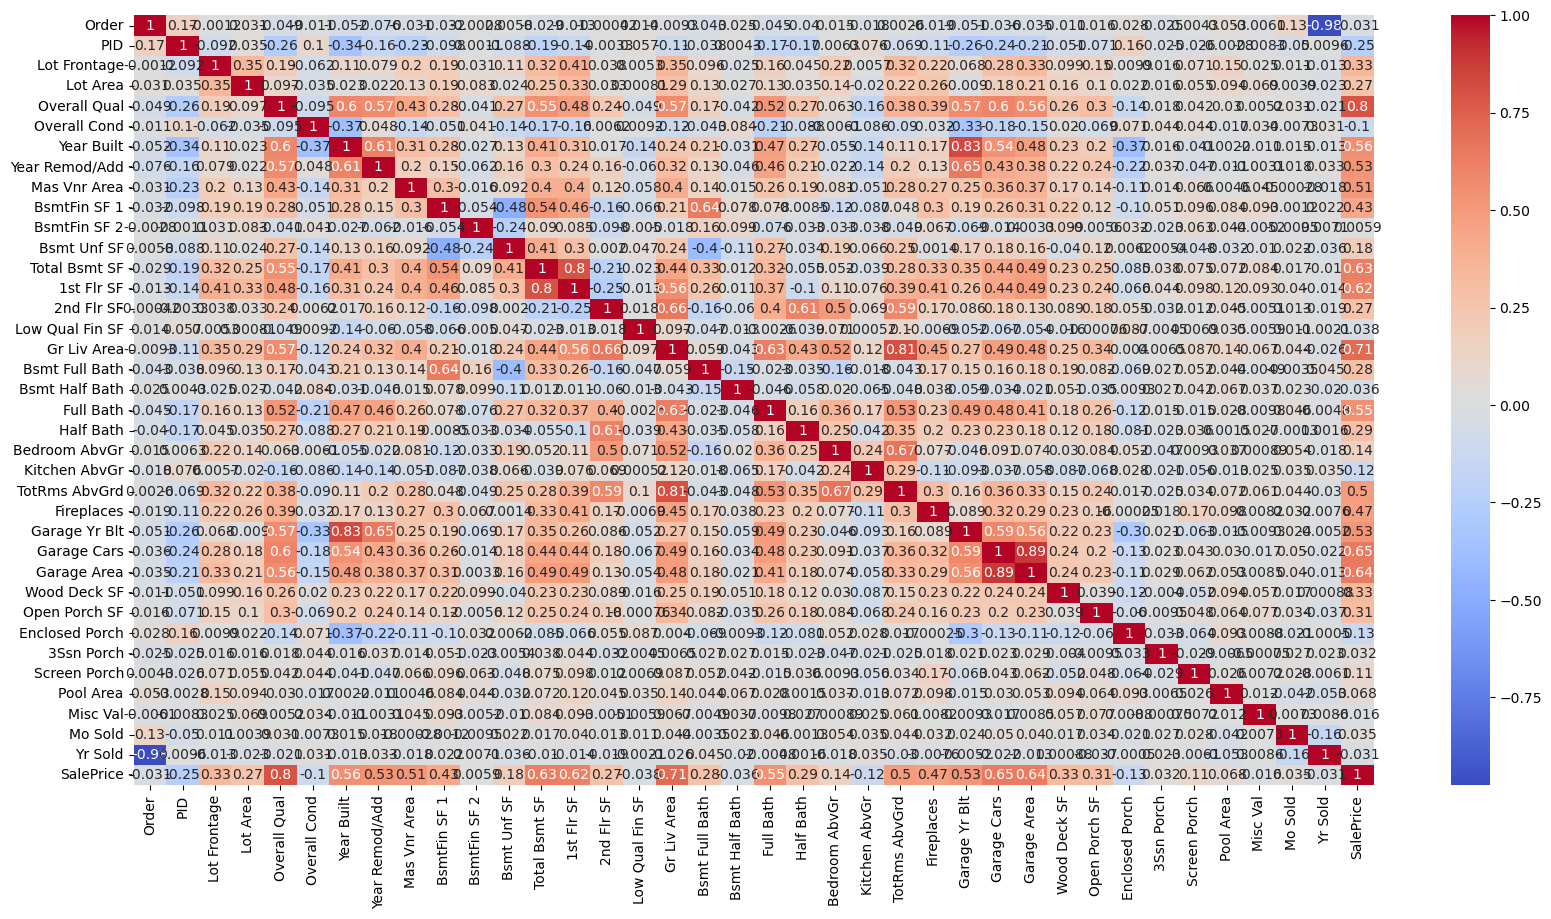

In [36]:
# heatmap to show correlation between the columns in the dataframe numeric columns
plt.figure(figsize=(20,10)) 
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.show()

In [13]:
df['MS SubClass'].describe()

count    2930.000000
mean       57.387372
std        42.638025
min        20.000000
25%        20.000000
50%        50.000000
75%        70.000000
max       190.000000
Name: MS SubClass, dtype: float64

In [19]:
# use px to  create a column cart for MS SubClass
fig = px.histogram(df, x='MS SubClass')
fig.show()

In [23]:
# this a code represanting a certain type of houses
df['MS SubClass']=df['MS SubClass'].astype('category')

In [28]:
# MS Zoning column chart 
fig = px.histogram(df, x='MS Zoning')
fig.show()

In [26]:
zoning_names = {
    "A (agr)": "Agriculture",
    "C (all)": "Commercial",
    "FV": "Floating Village Residential",
    "I (all)": "Industrial",
    "RH": "Residential High Density",
    "RL": "Residential Low Density",
    "RM": "Residential Medium Density",
}

unknown = set(df["MS Zoning"].dropna().unique()) - set(zoning_names)
if unknown:
    raise ValueError(f"Unmapped MS Zoning values: {unknown}")

df["MS Zoning"] = df["MS Zoning"].map(zoning_names).astype("category")

In [29]:
# histogram to Lot Frontage 
fig=px.histogram(df,x='Lot Frontage')
fig.show()

In [31]:
missing_frontage = df["Lot Frontage"].isna()

group_medians = df.groupby(
    ["Lot Shape", "Lot Config"],
    observed=True
)["Lot Frontage"].transform("median")

df.loc[missing_frontage, "Lot Frontage"] = group_medians[missing_frontage]

print("Missing frontage remaining:", df["Lot Frontage"].isna().sum())

Missing frontage remaining: 0


In [37]:
# draw a histogram for Lot Area
fig=px.histogram(df,x='Lot Area')
fig.show()

In [38]:
alley_names = {
    "Grvl": "Gravel",
    "Pave": "Paved",
    "NA": "No alley access",
}

df["Alley"] = (
    df["Alley"]
    .fillna("NA")
    .map(alley_names)
    .astype("category")
)

df["Alley"].value_counts()

Alley
No alley access    2732
Gravel              120
Paved                78
Name: count, dtype: int64

In [40]:
df["Condition 1"] = df["Condition 1"].replace({"Norm": "Normal"})

In [42]:
df["Condition 2"] = df["Condition 2"].replace({"Norm": "Normal"})

In [ ]:
# change column names to be more descriptive
df = df.rename(columns={
    "1st Flr SF": "First Floor Area",
    "2nd Flr SF": "Second Floor Area",
    "3Ssn Porch": "Three Season Porch Area",
    "Bsmt Half Bath": "Basement Half Bathroom Count",
    "Bsmt Full Bath": "Basement Full Bathroom Count",
    "Bldg Type": "Building Type",
    "bsmtFin SF 1": "Basement Finished Area 1",
    "bsmtFin SF 2": "Basement Finished Area 2"
})

In [44]:
# draw a bar chart for Bldg Type
fig = px.histogram(df, x='Bldg Type')
fig.show()

In [45]:
fig = px.histogram(df, x='Exterior 1st')
fig.show()

In [48]:
fig = px.histogram(df, x='Exterior 2nd')
fig.show()

In [47]:
df["Exterior 2nd"] = df["Exterior 2nd"].replace({
    "Brk Cmn": "BrkComm",
    "CmentBd": "CemntBd",
    "Wd Shng": "WdShing",
})

In [51]:
df2 = pd.read_csv("AmesHousing.csv", keep_default_na=False, na_values=[""])

df["Mas Vnr Type"] = (
    df2["Mas Vnr Type"]
    .replace("None", "No veneer")
    .astype("category")
)

In [56]:
# show 2 columns Mas Vnr Type , Mas Vnr area only ,group by Mas Vnr Type = no veneer
df[df["Mas Vnr Type"] == "No veneer"][["Mas Vnr Type", "Mas Vnr Area"]]


,Mas Vnr Type,Mas Vnr Area
1,No veneer,0.0
3,No veneer,0.0
4,No veneer,0.0
6,No veneer,0.0
7,No veneer,0.0
...,...,...
2924,No veneer,0.0
2925,No veneer,0.0
2926,No veneer,0.0
2927,No veneer,0.0


In [60]:
# write a code to replace the value in the column Mas Vnr Type to NAN when mas vnr type is no veneer and mas vnr area is greater than 0
df.loc[(df["Mas Vnr Type"] == "No veneer") & (df["Mas Vnr Area"] > 0), "Mas Vnr Type"] = np.nan

In [62]:
df["Mas Vnr Type"] = df["Mas Vnr Type"].fillna("No veneer")

In [63]:
df["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(0)

In [64]:
df.isna().sum()

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 82, dtype: int64

In [59]:
df.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,Residential Low Density,141.0,31770,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Normal,Normal,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,Residential High Density,80.0,11622,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Normal,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,No veneer,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,Residential Low Density,81.0,14267,Pave,No alley access,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Normal,Normal,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,Residential Low Density,93.0,11160,Pave,No alley access,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Normal,Normal,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,No veneer,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,Residential Low Density,74.0,13830,Pave,No alley access,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Normal,Normal,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,No veneer,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,Residential Low Density,78.0,9978,Pave,No alley access,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Normal,Normal,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,Residential Low Density,41.0,4920,Pave,No alley access,Reg,Lvl,AllPub,Inside,Gtl,StoneBr,Normal,Normal,TwnhsE,1Story,8,5,2001,2001,Gable,CompShg,CemntBd,CemntBd,No veneer,0.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,616.0,Unf,0.0,722.0,1338.0,GasA,Ex,Y,SBrkr,1338,0,0,1338,1.0,0.0,2,0,2,1,Gd,6,Typ,0,NaN,Attchd,2001.0,Fin,2.0,582.0,TA,TA,Y,0,0,170,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,Residential Low Density,43.0,5005,Pave,No alley access,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Normal,Normal,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,No veneer,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN